# Entrega 2: Simulación e inferencia — Airbnb Nueva York

**Estadística Computacional (INF280), Universidad Técnica Federico Santa María**  
**Grupo 25:** José Flores, Sebastian Alcaide, Pedro Ortiz y Miguel Primera  
**Tutor:** Cristobal Duarte  
**Dataset:** [Airbnb Open Data (NYC)](https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata), versión 1.

## Objetivo
Estimar las calificaciones medias de Manhattan y Brooklyn, cuantificar la incertidumbre de su diferencia y estudiar mediante simulación cómo el tamaño muestral afecta la capacidad de detectar una diferencia pequeña.

| Requisito de LEC2 | Sección |
|---|---|
| Parámetros vinculados a la Entrega 1 y estimación puntual | 2 y 3 |
| Origen, explicación e implementación propia de bootstrap | 4 |
| Distribuciones, comparación y estabilidad de bootstrap | 4 y 5 |
| Modelo, implementación e interpretación de Monte Carlo | 6 y 7 |
| Conclusiones, límites y reproducibilidad | 8 y 9 |

**Uso de IA en esta entrega:** ChatGPT/Codex apoyó el análisis, la implementación, las verificaciones y la redacción del notebook. Claude apoyó la revisión y la versión inicial de la presentación; ChatGPT/Codex realizó su actualización. El grupo es responsable del contenido y de su interpretación. La declaración de Claude/Gemini de la Entrega 1 corresponde a aquella entrega.


## Cómo estudiar este notebook

Las **18 celdas de código** están numeradas en comentarios. En cada una se indica su propósito y se explican las operaciones que conectan el código con la estadística. Primero lee la explicación Markdown de la sección, después el código y finalmente su salida.

**Variables que conviene reconocer:** `raw` es el CSV original; `df`, la tabla limpia; `pares`, los anuncios con distrito y calificación; `M`, las notas de Manhattan; `K`, las de Brooklyn. Usamos `K` porque `B` ya cuenta réplicas bootstrap. `delta` es la diferencia observada; `boot` contiene las remuestras; `mc_tabla` resume las simulaciones.

| Cantidad | Qué cuenta | Valor usado |
|---|---|---|
| $n_M,n_B$ | Anuncios de una muestra | 43.418 y 41.515 en el escenario original |
| $B$ | Remuestras bootstrap de esos datos | 20.000 |
| $R$ | Realizaciones por escenario y modelo Monte Carlo | 20.000 |

Aumentar $n$ cambia la información de cada muestra. Aumentar $B$ o $R$ mejora la aproximación computacional.


## 1. Reproducibilidad y continuidad de la limpieza

Este notebook funciona de forma independiente. Incluimos el CSV original en `data/`, por lo que la ejecución del paquete no necesita acceso a Kaggle. Si falta, se busca una copia local o se descarga **la versión 1** con `kagglehub`. No se utiliza una submuestra ni se reutiliza un kernel de la Entrega 1.

La limpieza conserva sus decisiones: eliminar duplicados exactos, corregir dos nombres de distrito, convertir las columnas monetarias, normalizar nombres, descartar cuatro columnas y sustituir valores físicamente imposibles por `NaN`. No imputamos calificaciones. Las exclusiones para el análisis se hacen solo en las columnas necesarias.

**Reproducibilidad numérica:** se incluyen el CSV, su SHA-256, las semillas y las versiones comprobadas en `requirements.txt`. NumPy no garantiza una secuencia idéntica entre todas sus versiones y plataformas [9]. Si cambia el entorno, pueden variar algunas cifras de simulación dentro de su error Monte Carlo. Las tablas de este notebook se generan desde la ejecución y son la referencia para la presentación. Oralmente expresamos la potencia original como «aproximadamente 53%».


In [1]:
# CELDA DE CÓDIGO 1/18 — Preparar herramientas, constantes y carpetas
# Propósito: fijar las condiciones de ejecución y guardar los resultados de forma ordenada.

# Path maneja rutas; hashlib identifica el CSV; json permite exportar resultados.
# NumPy hace cálculos y sorteos; pandas organiza tablas; SciPy aporta distribuciones.
# Matplotlib dibuja y display muestra tablas y explicaciones dentro del notebook.
from pathlib import Path
import hashlib
import json
import platform
import sys
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Las semillas inicializan los generadores aleatorios. Permiten repetir los sorteos
# en las condiciones de reproducibilidad indicadas en la explicación anterior.
SEED_BOOT = 20261004
SEED_MC = 20261005
# B cuenta remuestras bootstrap; R cuenta simulaciones POR escenario y modelo.
# No confundirlos con n: n es la cantidad de anuncios de una muestra.
B = 20000                        # réplicas bootstrap
R = 20000                        # realizaciones Monte Carlo por escenario
# ALPHA es el nivel nominal de la prueba; 0,05 equivale al 5%.
# La tolerancia de precisión se mide en puntos de calificación, no en porcentajes.
ALPHA = 0.05
TOL_PRECISION = 0.05              # precisión deseada, en puntos de calificación
UMBRALES = [0.05, 0.10, 0.20]     # referencias exploratorias de magnitud

# Funciona tanto desde entrega2/ como desde la raíz del repositorio.
BASE = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd() / 'entrega2'
if not BASE.exists():
    BASE = Path.cwd()
# OUT es la carpeta de salida. El operador / de Path une carpetas y nombres.
OUT = BASE / 'resultados'
OUT.mkdir(parents=True, exist_ok=True)
# Estas opciones afectan la apariencia de los gráficos, no los cálculos.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
COLOR_M, COLOR_B = '#087e8b', '#c85a43'
pd.set_option('display.precision', 6)

# Registramos las versiones para interpretar posibles diferencias entre equipos.
versiones = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scipy': scipy.__version__,
            'matplotlib': matplotlib.__version__}
display(pd.Series(versiones, name='versión'))


python        3.12.14
numpy           2.3.5
pandas          2.2.3
scipy          1.17.0
matplotlib     3.10.8
Name: versión, dtype: object

In [2]:
# CELDA DE CÓDIGO 2/18 — Cargar el CSV y reproducir la limpieza
# Propósito: continuar desde los mismos datos y decisiones de la Entrega 1.

# Buscamos primero el CSV incluido en el paquete. Así evitamos depender de internet.
candidatos = [BASE / 'data' / 'Airbnb_Open_Data.csv',
              Path.cwd() / 'Airbnb_Open_Data.csv',
              Path.home() / '.cache' / 'kagglehub' / 'datasets' /
              'arianazmoudeh' / 'airbnbopendata' / 'versions' / '1' /
              'Airbnb_Open_Data.csv']
# next devuelve la primera ruta existente; None señala que ninguna fue encontrada.
CSV = next((p for p in candidatos if p.is_file()), None)
# La descarga es una alternativa si falta el CSV y kagglehub está instalado.
# Al extraer el paquete completo se usa la copia local incluida.
if CSV is None:
    import kagglehub
    descargado = Path(kagglehub.dataset_download('arianazmoudeh/airbnbopendata/versions/1'))
    CSV = descargado / 'Airbnb_Open_Data.csv'
# El SHA-256 funciona como una huella del archivo: detecta cambios en sus bytes.
# Una huella distinta detiene el análisis para no mezclar versiones de los datos.
sha256 = hashlib.sha256(CSV.read_bytes()).hexdigest()
SHA_ESPERADO = 'ecb59a7598d2aaf7dc2ed00c724648a319d93a916a3d4767e2bed0dbe0f1a7f8'
if sha256 != SHA_ESPERADO:
    raise ValueError('El SHA-256 del CSV no corresponde a los datos comprobados de la Entrega 1.')
# raw conserva la tabla original; df será la versión limpia.
raw = pd.read_csv(CSV, low_memory=False)
print('Dataset:', CSV.name)
print('Dimensiones originales:', raw.shape)
print('SHA-256:', sha256)

def limpiar_entrega1(datos):
    """Reproduce las decisiones de limpieza de la Entrega 1."""
    # Quitamos filas idénticas para no contar dos veces el mismo registro.
    # copy permite trabajar sobre una tabla separada.
    d = datos.drop_duplicates().copy()
    # Normalizamos nombres de columnas para que sean fáciles de usar en Python.
    d.columns = d.columns.str.strip().str.lower().str.replace(' ', '_', regex=False)
    # Corregimos dos errores de escritura: no deben convertirse en distritos nuevos.
    d['neighbourhood_group'] = d['neighbourhood_group'].replace(
        {'manhatan': 'Manhattan', 'brookln': 'Brooklyn'})
    # Quitamos símbolos monetarios y convertimos texto a números.
    # errors=coerce transforma textos inválidos en NaN (dato ausente).
    for col in ['price', 'service_fee']:
        texto = d[col].astype('string').str.replace('$', '', regex=False)
        texto = texto.str.replace(',', '', regex=False).str.strip()
        d[col] = pd.to_numeric(texto, errors='coerce')
    # Estas cuatro columnas se eliminaron también en la Entrega 1.
    d = d.drop(columns=['license', 'house_rules', 'country', 'country_code'])
    # Estas expresiones producen máscaras booleanas: True indica una fila inválida.
    # ~ invierte una condición; & combina condiciones con un AND elemento a elemento.
    # Un año no tiene más de 365 días de disponibilidad ni noches mínimas negativas.
    inv_a = ~d['availability_365'].between(0, 365) & d['availability_365'].notna()
    inv_n = d['minimum_nights'] < 0
    auditoria = {'filas_originales': len(datos),
                 'duplicados_eliminados': len(datos) - len(d),
                 'disponibilidad_invalida': int(inv_a.sum()),
                 'noches_negativas': int(inv_n.sum()),
                 'filas_limpias': len(d), 'columnas_limpias': d.shape[1]}
    # Sustituimos valores imposibles por NaN, sin eliminar sus anuncios completos.
    # Un error en disponibilidad no obliga a descartar una calificación válida.
    d.loc[inv_a, 'availability_365'] = np.nan
    d.loc[inv_n, 'minimum_nights'] = np.nan
    return d, auditoria

df, auditoria = limpiar_entrega1(raw)
# assert detiene la ejecución si una condición esperada no se cumple.
# Estos controles comprueban que la limpieza reproduce la entrega anterior.
assert raw.shape == (102599, 26), 'La versión de los datos no coincide con la Entrega 1.'
assert df.shape == (102058, 22)
assert auditoria['duplicados_eliminados'] == 541
assert auditoria['disponibilidad_invalida'] == 3185
assert auditoria['noches_negativas'] == 13
display(pd.Series(auditoria, name='auditoría'))


filas_originales           102599
duplicados_eliminados         541
disponibilidad_invalida      3185
noches_negativas               13
filas_limpias              102058
columnas_limpias               22
Name: auditoría, dtype: int64

Dataset: Airbnb_Open_Data.csv
Dimensiones originales: (102599, 26)
SHA-256: ecb59a7598d2aaf7dc2ed00c724648a319d93a916a3d4767e2bed0dbe0f1a7f8


In [3]:
# CELDA DE CÓDIGO 3/18 — Elegir las observaciones y conectar con la Entrega 1
# Propósito: definir qué anuncios analizamos y justificar la comparación Manhattan–Brooklyn.

# Para este análisis necesitamos solamente distrito y calificación.
# dropna excluye filas incompletas EN ESAS DOS COLUMNAS, sin imputar notas.
pares = df[['neighbourhood_group', 'review_rate_number']].dropna().copy()
assert pares['review_rate_number'].isin([1, 2, 3, 4, 5]).all()
assert len(pares) == 101712
# groupby agrupa por distrito; agg calcula tamaño, media y desviación estándar.
# El error estándar de una media es desviación / raíz del tamaño muestral.
resumen_distritos = pares.groupby('neighbourhood_group')['review_rate_number'].agg(
    n='size', media='mean', desviacion='std')
resumen_distritos['EE_media'] = resumen_distritos['desviacion'] / np.sqrt(resumen_distritos['n'])
display(resumen_distritos)
print('Filas excluidas por falta de distrito o calificación:', len(df) - len(pares))

# Elegimos los dos distritos con más anuncios; no los de medias más extremas.
seleccion = pares[pares['neighbourhood_group'].isin(['Manhattan', 'Brooklyn'])]
# loc selecciona filas y una columna. to_numpy obtiene un vector numérico.
# M contiene Manhattan y K contiene Brooklyn: B ya está reservado al bootstrap.
M = seleccion.loc[seleccion['neighbourhood_group'].eq('Manhattan'), 'review_rate_number'].to_numpy()
K = seleccion.loc[seleccion['neighbourhood_group'].eq('Brooklyn'), 'review_rate_number'].to_numpy()
assert (len(M), len(K)) == (43418, 41515)
# Revisar anfitriones repetidos ayuda a explorar dependencia.
# Que no se repitan IDs no demuestra independencia espacial o temporal.
control_hosts = df.loc[seleccion.index, 'host_id']
print('Pares utilizados:', len(seleccion))
print('IDs de anfitrión repetidos en el subconjunto:', int(control_hosts.duplicated().sum()))

# Continuidad: comparación global de la Entrega 1, con las mismas filas completas.
# Recalculamos el antecedente global, no lo sustituimos por el contraste de dos grupos.
# El * de f_oneway desempaqueta la lista: entrega un vector por distrito al ANOVA.
grupos_e1 = [g['review_rate_number'].to_numpy() for _, g in pares.groupby('neighbourhood_group')]
f_e1, p_anova_e1 = stats.f_oneway(*grupos_e1)
# La tabla cruzada cuenta anuncios por distrito y categoría 1–5.
# Chi-cuadrado evalúa independencia; ANOVA evalúa igualdad de medias.
# V de Cramér mide la intensidad de asociación categórica, no una diferencia de medias.
tabla_e1 = pd.crosstab(pares['neighbourhood_group'], pares['review_rate_number'])
chi2_e1, p_chi2_e1, gl_e1, _ = stats.chi2_contingency(tabla_e1)
v_e1 = np.sqrt(chi2_e1 / (len(pares) * (min(tabla_e1.shape)-1)))
assert abs(f_e1 - 11.3048) < 5e-5 and abs(v_e1 - 0.0200) < 5e-5
print(f'Entrega 1: ANOVA F={f_e1:.4f}, p={p_anova_e1:.3e}; V de Cramér={v_e1:.4f}')


,n,media,desviacion,EE_media
neighbourhood_group,,,,
Bronx,2677,3.331341,1.212648,0.023437
Brooklyn,41515,3.258461,1.295044,0.006356
Manhattan,43418,3.276521,1.290677,0.006194
Queens,13159,3.330420,1.248600,0.010885
Staten Island,943,3.404030,1.255588,0.040888


Filas excluidas por falta de distrito o calificación: 346
Pares utilizados: 84933
IDs de anfitrión repetidos en el subconjunto: 0
Entrega 1: ANOVA F=11.3048, p=3.596e-09; V de Cramér=0.0200


## 2. Pregunta, población de referencia y parámetros

### 2.1 Continuidad con la Entrega 1

La pregunta principal fue si el distrito se relacionaba con la calificación registrada. El ANOVA contrastó $H_0:\mu_{Bronx}=\mu_{Brooklyn}=\mu_{Manhattan}=\mu_{Queens}=\mu_{Staten\ Island}$ frente a $H_1$: al menos una media difiere. El notebook de la Entrega 1 reportó $F=11{,}3048$ y un p-valor redondeado a `0.0000`; aquí lo expresamos como **$p<0{,}001$**, sin afirmar que sea cero. La prueba rechazó la igualdad de medias bajo sus supuestos.

Por separado, la tabla distrito × puntuación dio $\chi^2=162{,}5295$, 16 grados de libertad y **V de Cramér $=0{,}0200$**, una asociación pequeña en la distribución de categorías. ANOVA y chi-cuadrado contrastan hipótesis distintas: igualdad de medias e independencia, respectivamente. Un efecto pequeño no prueba irrelevancia práctica ni ausencia de causalidad.

### 2.2 Parámetros de esta entrega

La Entrega 1 preguntó si las calificaciones variaban entre los cinco distritos. Esta entrega cuantifica un contraste específico dentro de esa pregunta: **¿cuánto difieren las calificaciones medias de los anuncios de Manhattan y Brooklyn, y con qué precisión podemos estimarlas?** Elegimos estos distritos por su tamaño y peso en la oferta registrada, sin seleccionar el mayor y el menor promedio observado. El contraste no responde por sí solo a la comparación global de los cinco distritos.

Seleccionamos **dos parámetros poblacionales**:

$$
\mu_M=E(Y\mid D=\text{Manhattan}),\qquad
\mu_B=E(Y\mid D=\text{Brooklyn}).
$$

Su contraste derivado es $\Delta=\mu_M-\mu_B$, medido en **puntos de calificación**. $\Delta>0$ representa una media mayor en Manhattan. Los estimadores son $\bar Y_M$, $\bar Y_B$ y $\widehat\Delta=\bar Y_M-\bar Y_B$.

**Unidad de análisis:** un anuncio con calificación y distrito observados. Cada anuncio pesa lo mismo. No disponemos de las calificaciones individuales de huéspedes, por lo que no estimamos una media por huésped ni ponderamos por cantidad de reseñas.

**Alcance poblacional:** la inferencia describe un modelo de anuncios comparables a los registrados en esta fuente, condicionado a tener calificación disponible. El dataset no documenta un muestreo probabilístico del mercado de NYC. Interpretamos los intervalos como incertidumbre bajo el modelo de muestreo adoptado. Si los anuncios registrados fueran toda la población de interés, sus medias serían descriptivas exactas y no necesitarían intervalos por muestreo.

**Supuestos:** anuncios independientes dentro de cada distrito y entre distritos, con distribución estable y varianza finita. Los IDs de anfitrión no se repiten en el subconjunto elegido, pero eso no garantiza independencia espacial o temporal. La escala 1–5 es ordinal. El uso de medias supone que sus distancias numéricas son comparables, de modo que el resultado debe leerse como una media de puntuaciones codificadas.


## 3. Estimación puntual clásica y propiedades

Para cada distrito $g$, usamos:

$$
\widehat\mu_g=\bar Y_g=\frac{1}{n_g}\sum_iY_{gi},\qquad
\widehat{EE}(\bar Y_g)=\frac{s_g}{\sqrt{n_g}}.
$$

Para el contraste entre muestras independientes:

$$
\widehat\Delta=\bar Y_M-\bar Y_B,\qquad
\widehat{EE}(\widehat\Delta)=\sqrt{\frac{s_M^2}{n_M}+\frac{s_B^2}{n_B}}.
$$

Además de la estimación puntual solicitada, incluimos IC del 95% como apoyo: $\widehat\theta\pm t_{0.975,\nu}\widehat{EE}$. En las medias usamos $\nu=n_g-1$. En la diferencia usamos los grados de libertad de Welch:

$$
\nu=\frac{(s_M^2/n_M+s_B^2/n_B)^2}
{(s_M^2/n_M)^2/(n_M-1)+(s_B^2/n_B)^2/(n_B-1)}.
$$

La distribución de las puntuaciones no es normal. Por ello, estos intervalos t son **aproximaciones de muestra grande**, respaldadas por la distribución asintótica de las medias.

- **Sesgo:** cuando las observaciones tienen la esperanza del parámetro objetivo, $E(\bar Y_g)=\mu_g$ y $E(\widehat\Delta)=\Delta$. Son insesgados bajo el modelo. La independencia por sí sola no garantiza que la muestra represente el parámetro objetivo y no elimina sesgos de selección o de datos faltantes.
- **Consistencia:** por la ley de los grandes números, las medias convergen a sus parámetros cuando crecen los tamaños de ambos grupos. Las puntuaciones están acotadas, por lo que la varianza es finita.
- **Eficiencia:** la media tiene varianza $\sigma_g^2/n_g$ y minimiza la varianza entre estimadores lineales insesgados con observaciones independientes de igual varianza dentro del grupo. No afirmamos eficiencia universal entre todos los estimadores o diseños.


In [4]:
# CELDA DE CÓDIGO 4/18 — Calcular las estimaciones y los intervalos clásicos
# Propósito: estimar las dos medias y su diferencia, con una referencia analítica de incertidumbre.

# La función devuelve cuatro valores: media, error estándar y límites del IC.
# El parámetro alpha controla el nivel: 1-alpha = 0,95 con los valores de esta entrega.
def intervalo_media(x, alpha=ALPHA):
    n = len(x)
    estimacion = float(np.mean(x))
    # ddof=1 utiliza n-1 al estimar la varianza muestral.
    # La desviación describe notas individuales; dividir por sqrt(n) da el error de la media.
    ee = float(np.std(x, ddof=1) / np.sqrt(n))
    # ppf obtiene un cuantil. Para un IC bilateral del 95% usamos el cuantil 97,5%.
    # Las notas son discretas; el intervalo t se usa como aproximación de muestra grande.
    q = stats.t.ppf(1 - alpha / 2, n - 1)
    return estimacion, ee, estimacion - q * ee, estimacion + q * ee

# Para dos muestras independientes, las varianzas de sus medias se suman.
# Welch permite varianzas distintas entre Manhattan y Brooklyn.
def intervalo_diferencia(x, y, alpha=ALPHA):
    a = np.var(x, ddof=1) / len(x)
    b = np.var(y, ddof=1) / len(y)
    ee = float(np.sqrt(a + b))
    # nu son los grados de libertad aproximados de Welch: determinan el cuantil t.
    nu = (a + b)**2 / (a**2 / (len(x)-1) + b**2 / (len(y)-1))
    estimacion = float(np.mean(x) - np.mean(y))
    q = stats.t.ppf(1 - alpha / 2, nu)
    return estimacion, ee, estimacion - q * ee, estimacion + q * ee, float(nu)

# Desempaquetamos las tuplas que devuelven las funciones.
# mu_m y mu_b contienen ESTIMACIONES observadas, aunque sus nombres parezcan parámetros.
mu_m, ee_m, lo_m, hi_m = intervalo_media(M)
mu_b, ee_b, lo_b, hi_b = intervalo_media(K)
delta, ee_delta, lo_delta, hi_delta, nu_delta = intervalo_diferencia(M, K)
# Organizamos los resultados en una tabla que después compararemos con el bootstrap.
# En la fila de diferencia, n resume el total; el cálculo usa ambos tamaños por separado.
clasica = pd.DataFrame([
    ['Media Manhattan', len(M), mu_m, ee_m, lo_m, hi_m],
    ['Media Brooklyn', len(K), mu_b, ee_b, lo_b, hi_b],
    ['Diferencia M − B', len(M)+len(K), delta, ee_delta, lo_delta, hi_delta]],
    columns=['estimador', 'n', 'estimacion', 'EE_clasico', 'IC95_inf', 'IC95_sup']).set_index('estimador')
display(clasica)
display(Markdown(f'**Resultado puntual:** Manhattan: {mu_m:.4f}; Brooklyn: {mu_b:.4f}. '
                 f'La diferencia es **{delta:.4f} puntos**, con IC clásico del 95% '
                 f'[{lo_delta:.4f}, {hi_delta:.4f}].'))


,n,estimacion,EE_clasico,IC95_inf,IC95_sup
estimador,,,,,
Media Manhattan,43418,3.276521,0.006194,3.264381,3.288662
Media Brooklyn,41515,3.258461,0.006356,3.246003,3.270919
Diferencia M − B,84933,0.018060,0.008875,0.000665,0.035455


**Resultado puntual:** Manhattan: 3.2765; Brooklyn: 3.2585. La diferencia es **0.0181 puntos**, con IC clásico del 95% [0.0007, 0.0355].

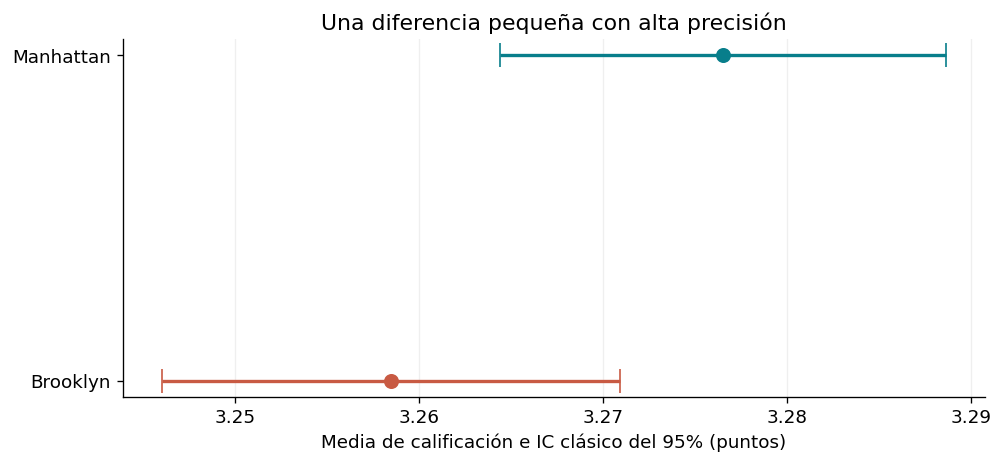

In [5]:
# CELDA DE CÓDIGO 5/18 — Visualizar las medias y sus intervalos
# Propósito: mostrar la magnitud de las medias y la incertidumbre calculada en la celda anterior.

# fig es la figura completa y ax su área de dibujo.
fig, ax = plt.subplots(figsize=(8.5, 4))
for j, (nombre, media, lo, hi, color) in enumerate([
        ('Brooklyn', mu_b, lo_b, hi_b, COLOR_B),
        ('Manhattan', mu_m, lo_m, hi_m, COLOR_M)]):
    # El punto marca la media y las barras llegan a los límites del IC.
    # xerr recibe distancias desde el punto, no los límites del intervalo.
    ax.errorbar(media, j, xerr=[[media-lo], [hi-media]], fmt='o',
                color=color, capsize=7, markersize=8, linewidth=2)
# Etiquetas, título y rejilla hacen el gráfico legible.
# La significancia de la diferencia se evalúa con su propio IC, no solo mirando
# si se superponen los IC de las dos medias.
ax.set_yticks([0, 1], ['Brooklyn', 'Manhattan'])
ax.set_xlabel('Media de calificación e IC clásico del 95% (puntos)')
ax.set_title('Una diferencia pequeña con alta precisión')
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
# Guardamos la imagen y plt.show la muestra en el notebook.
fig.savefig(OUT / '01_medias_ic.png', dpi=180)
plt.show()


## 4. Bootstrap: fundamento e implementación propia

### 4.1 Origen, motivación y relevancia moderna

Bradley Efron presentó el bootstrap en 1979 en *Bootstrap Methods: Another Look at the Jackknife* [1]. El método aproxima la distribución muestral de un estadístico utilizando la distribución empírica de los datos. Es útil cuando resulta difícil derivar analíticamente su incertidumbre. En este trabajo sirve también como comparación computacional con las fórmulas de la media.

**Relevancia en la estadística moderna:** el bootstrap permite evaluar la incertidumbre de medianas, cuantiles, coeficientes de regresión y otros estadísticos cuya distribución es difícil de derivar. Su uso computacional facilita obtener errores estándar e intervalos sin resolver una fórmula analítica para cada estadístico [1, 2]. Su validez sigue dependiendo del diseño y de los supuestos: si existe dependencia, se necesitan métodos adaptados, como remuestrear grupos o bloques.

En esta entrega, la media sí tiene una fórmula conocida. Eso permite comprobar la implementación propia frente a una referencia exacta condicional y comparar el enfoque clásico con el remuestreo.

### 4.2 Procedimiento

1. Calcular las medias y su diferencia en las muestras observadas.
2. Sortear **con reemplazo** $n_M$ índices de Manhattan y, de forma independiente, $n_B$ de Brooklyn. Cada registro tiene probabilidad $1/n_g$ dentro de su distrito.
3. Calcular $\bar Y_M^*$, $\bar Y_B^*$ y $\widehat\Delta^*=\bar Y_M^*-\bar Y_B^*$.
4. Repetir el procedimiento $B=20.000$ veces.
5. Usar la desviación estándar de las réplicas como EE bootstrap y sus percentiles 2,5 y 97,5 como IC percentil.

El remuestreo mantiene los tamaños de cada distrito. **Una réplica bootstrap conserva el tamaño original**, aunque algunos anuncios se repitan y otros no aparezcan. Remuestrear no añade información nueva ni corrige automáticamente problemas de representatividad.

La siguiente función usa NumPy para sortear índices y calcular medias. **No utiliza `scipy.stats.bootstrap`, `sklearn.utils.resample` ni otra implementación directa de bootstrap.** Los lotes limitan memoria sin alterar el procedimiento.


### Ejemplo para leer la función bootstrap

Si los datos fueran `[1, 3, 5]`, una remuestra posible sería `[5, 5, 1]`. Tiene **tres observaciones**, como el original, pero un dato se repite y otros pueden faltar. Su media cambia de 3 a $11/3$. Al repetir esto muchas veces vemos cómo varía la media. Sin reemplazo y tomando todos los datos, solo cambiaríamos su orden y la media siempre sería la misma.

En nuestro código, `indices_x` guarda posiciones sorteadas; `x[indices_x]` recupera las notas; `mean(axis=1)` calcula una media por remuestra. La función hace lo mismo para el otro distrito y resta ambas medias.


In [6]:
# CELDA DE CÓDIGO 6/18 — Implementar y ejecutar nuestro bootstrap
# Propósito: aproximar la distribución de las medias y de su diferencia remuestreando los anuncios.

def bootstrap_medias(x, y, replicas=20000, seed=20261004, lote=16):
    """Bootstrap no paramétrico independiente dentro de cada distrito.

    Devuelve una fila por réplica y columnas [media_x, media_y, diferencia].
    El parámetro lote controla memoria, no el tamaño de las remuestras.
    """
    # Convertimos las entradas a vectores numéricos y comprobamos que sean utilizables.
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if x.ndim != 1 or y.ndim != 1 or min(len(x), len(y)) < 2:
        raise ValueError('Se requieren dos vectores con al menos dos datos.')
    if not np.isfinite(x).all() or not np.isfinite(y).all():
        raise ValueError('Resolver los datos faltantes antes del remuestreo.')
    if replicas < 2 or lote < 1:
        raise ValueError('replicas >= 2 y lote >= 1.')
    # Flujos independientes: un distrito no afecta los sorteos del otro.
    # Creamos dos flujos pseudoaleatorios para separar los sorteos de los distritos.
    # Esto implementa el remuestreo independiente supuesto por el modelo.
    semillas = np.random.SeedSequence(seed).spawn(2)
    rng_x, rng_y = [np.random.default_rng(s) for s in semillas]
    # Reservamos una matriz B×3: cada fila es una réplica; las columnas son
    # media de Manhattan, media de Brooklyn y diferencia M−B. empty se rellena después.
    resultado = np.empty((replicas, 3), dtype=float)
    # Procesamos como máximo 16 réplicas a la vez para limitar el uso de memoria.
    # Cada remuestra sigue teniendo n_M o n_B anuncios: lote NO es tamaño de muestra.
    for inicio in range(0, replicas, lote):
        fin = min(inicio + lote, replicas)
        # integers sortea índices entre 0 y len(x)-1; el límite superior queda excluido.
        # Los índices pueden repetirse: eso produce el muestreo CON REEMPLAZO.
        indices_x = rng_x.integers(0, len(x), size=(fin-inicio, len(x)))
        # x[indices_x] reúne las notas sorteadas. Cada fila es una remuestra completa.
        # mean(axis=1) promedia sus columnas y devuelve una media por réplica.
        resultado[inicio:fin, 0] = x[indices_x].mean(axis=1)
        indices_y = rng_y.integers(0, len(y), size=(fin-inicio, len(y)))
        resultado[inicio:fin, 1] = y[indices_y].mean(axis=1)
    # [:, 2] selecciona la tercera columna de todas las filas.
    # Restamos las dos medias DE LA MISMA réplica.
    resultado[:, 2] = resultado[:, 0] - resultado[:, 1]
    return resultado

# Ejecutamos la función propia. NumPy aporta sorteos y operaciones,
# pero no llamamos una función de biblioteca que implemente el bootstrap por nosotros.
boot = bootstrap_medias(M, K, replicas=B, seed=SEED_BOOT)
# axis=0 resume cada columna entre las B réplicas.
# La desviación de réplicas estima el EE; quantile obtiene los percentiles del IC.
# El promedio de réplicas menos el valor observado estima el sesgo bootstrap.
# Para estas medias, su valor teórico condicional es cero; B finito deja error numérico.
boot_tabla = pd.DataFrame({
    'promedio_replicas': boot.mean(axis=0),
    'sesgo_boot_estimado': boot.mean(axis=0) - clasica['estimacion'].to_numpy(),
    'EE_boot': boot.std(axis=0, ddof=1),
    'IC95_boot_inf': np.quantile(boot, 0.025, axis=0),
    'IC95_boot_sup': np.quantile(boot, 0.975, axis=0)}, index=clasica.index)
display(boot_tabla)


,promedio_replicas,sesgo_boot_estimado,EE_boot,IC95_boot_inf,IC95_boot_sup
estimador,,,,,
Media Manhattan,3.276553,0.000032,0.006239,3.264383,3.288866
Media Brooklyn,3.258452,-0.000009,0.006325,3.246127,3.270746
Diferencia M − B,0.018101,0.000040,0.008844,0.000550,0.035416


### 4.3 Qué significan los resultados bootstrap

El **estimador puntual principal** sigue siendo la media observada o la diferencia observada. El promedio de las réplicas es una comprobación de centrado, no un estimador necesariamente mejor. La cantidad $\overline{\widehat\theta^*}-\widehat\theta$ estima el sesgo bajo la distribución empírica.

Para la media, $E^*(\bar Y_g^*)=\bar Y_g$ exactamente. El sesgo bootstrap teórico es cero y el pequeño sesgo numérico procede de usar un número finito de réplicas. Además,

$$
\operatorname{Var}^*(\bar Y_g^*)=\frac{n_g-1}{n_g}\frac{s_g^2}{n_g}.
$$

Esta identidad permite contrastar nuestra simulación con una referencia analítica. El bootstrap describe variación bajo la distribución empírica [2]. Un IC del 95% se refiere a la cobertura del procedimiento en muestreos repetidos, **no** a una probabilidad posterior del 95% sobre el parámetro fijo.


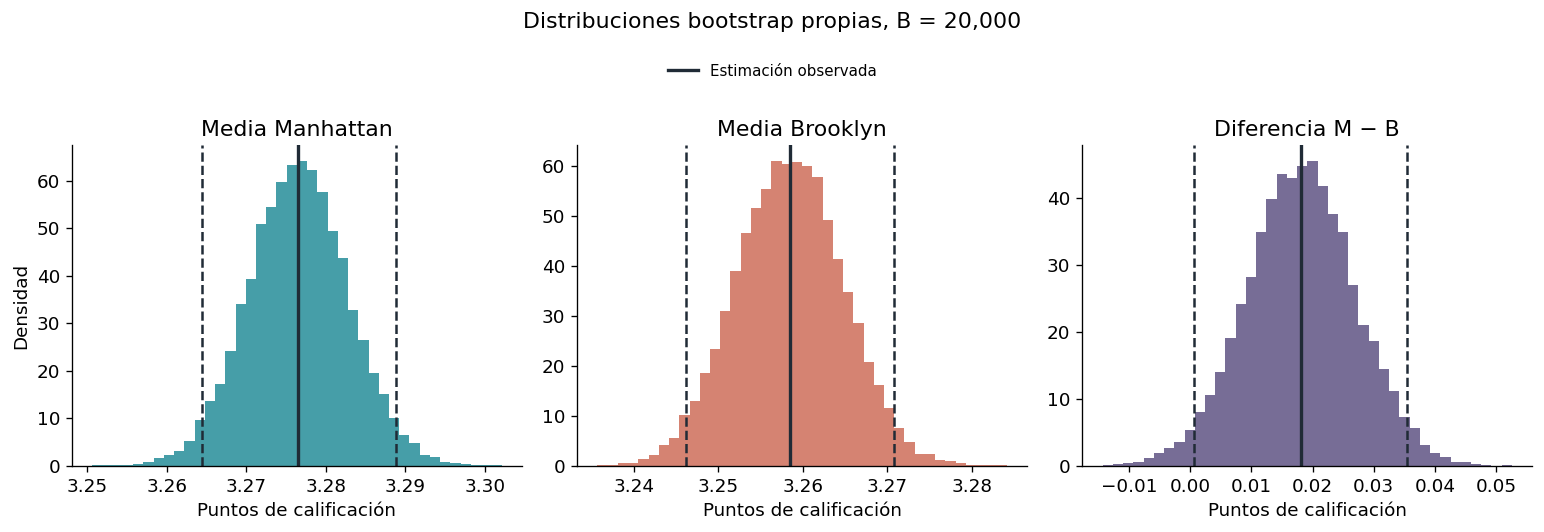

In [7]:
# CELDA DE CÓDIGO 7/18 — Dibujar las distribuciones bootstrap
# Propósito: observar cómo varían los tres estimadores entre remuestras.

# Creamos tres paneles: media de Manhattan, media de Brooklyn y diferencia.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for j, (ax, nombre, color) in enumerate(zip(axes, clasica.index, [COLOR_M, COLOR_B, '#493c73'])):
    # El histograma contiene ESTIMACIONES bootstrap, no calificaciones individuales.
    # density=True normaliza el área total a 1; una altura de densidad puede superar 1.
    ax.hist(boot[:, j], bins=40, density=True, color=color, alpha=0.75)
    # La línea continua marca la estimación observada; las discontinuas,
    # los percentiles 2,5 y 97,5 de las réplicas.
    ax.axvline(clasica.iloc[j]['estimacion'], color='#202b36', linewidth=2,
               label='Estimación observada')
    for q in [0.025, 0.975]:
        ax.axvline(np.quantile(boot[:, j], q), color='#202b36', linestyle='--')
    ax.set_title(nombre)
    ax.set_xlabel('Puntos de calificación')
axes[0].set_ylabel('Densidad')
# Situamos la leyenda fuera de las barras para que no oculte la distribución.
fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center',
           bbox_to_anchor=(0.5, 1.02), fontsize=9, frameon=False)
fig.suptitle(f'Distribuciones bootstrap propias, B = {B:,}', y=1.10)
fig.tight_layout()
fig.savefig(OUT / '02_bootstrap_distribuciones.png', dpi=180, bbox_inches='tight')
plt.show()


In [8]:
# CELDA DE CÓDIGO 8/18 — Comprobar la estabilidad y el EE bootstrap
# Propósito: evaluar el error numérico del remuestreo y contrastar la implementación con una fórmula.

filas_estabilidad = []
# Comparamos prefijos de las mismas B réplicas, no nuevas simulaciones independientes.
for b in [500, 2500, 5000, 10000, B]:
    # [:b, 2] toma las primeras b diferencias bootstrap.
    # Calculamos su centro, dispersión y percentiles para ver si se estabilizan.
    v = boot[:b, 2]
    filas_estabilidad.append([b, v.mean(), v.std(ddof=1),
                             *np.quantile(v, [0.025, 0.975])])
estabilidad_boot = pd.DataFrame(filas_estabilidad,
    columns=['B', 'promedio_delta', 'EE_delta', 'IC95_inf', 'IC95_sup'])
display(estabilidad_boot)

# Referencia exacta condicional para el bootstrap de estas medias.
# Estas fórmulas dan el EE EXACTO dentro de la distribución empírica de las medias.
# El factor (n-1)/n distingue la varianza empírica de la varianza muestral con ddof=1.
# No es una garantía de que el modelo represente toda la población de NYC.
ee_boot_exactos = np.array([
    np.sqrt((len(M)-1)/len(M)) * ee_m,
    np.sqrt((len(K)-1)/len(K)) * ee_b,
    np.sqrt((len(M)-1)/len(M)*ee_m**2 + (len(K)-1)/len(K)*ee_b**2)])
check_boot = pd.DataFrame({'EE_boot_simulado': boot.std(axis=0, ddof=1),
    'EE_boot_teorico': ee_boot_exactos}, index=clasica.index)
# Una razón cercana a 1 da error relativo cercano a 0: simulación y fórmula concuerdan.
# Aumentar B mejora esta aproximación numérica; no añade anuncios reales.
check_boot['error_relativo'] = check_boot['EE_boot_simulado'] / check_boot['EE_boot_teorico'] - 1
display(check_boot)
display(Markdown(f'Con {B:,} réplicas, el EE bootstrap de la diferencia es '
                 f'{boot[:,2].std(ddof=1):.6f}, frente a {ee_boot_exactos[2]:.6f} '
                 f'como referencia condicional exacta. La tabla muestra la estabilidad '
                 f'al aumentar B. Más réplicas reducen el error de simulación, '
                 f'pero no el error asociado al tamaño de la muestra original.'))


,B,promedio_delta,EE_delta,IC95_inf,IC95_sup
0,500,0.017686,0.008832,-0.000635,0.034765
1,2500,0.018007,0.008914,-0.000063,0.035203
2,5000,0.018078,0.008798,0.000661,0.035351
3,10000,0.018123,0.008860,0.000446,0.035433
4,20000,0.018101,0.008844,0.000550,0.035416


,EE_boot_simulado,EE_boot_teorico,error_relativo
estimador,,,
Media Manhattan,0.006239,0.006194,0.007206
Media Brooklyn,0.006325,0.006356,-0.004910
Diferencia M − B,0.008844,0.008875,-0.003499


Con 20,000 réplicas, el EE bootstrap de la diferencia es 0.008844, frente a 0.008875 como referencia condicional exacta. La tabla muestra la estabilidad al aumentar B. Más réplicas reducen el error de simulación, pero no el error asociado al tamaño de la muestra original.

## 5. Comparación clásica y bootstrap

Comparamos el mismo estimador, el mismo subconjunto y la misma unidad de medida. El EE clásico usa una fórmula para medias independientes. El bootstrap reproduce la variación del estadístico mediante remuestras. Esperamos similitud porque el estimador es una media y los tamaños de muestra son grandes.

El bootstrap aporta una distribución visible y se puede extender a estadísticos con fórmulas menos simples. Aquí no sustituye la verificación de supuestos. Sus límites incluyen error numérico por $B$ finito, dependencia no modelada, datos ausentes y cobertura aproximada del IC percentil.


In [9]:
# CELDA DE CÓDIGO 9/18 — Comparar ambos métodos y explorar la magnitud
# Propósito: responder si la incertidumbre calculada por fórmulas y remuestreo resulta compatible.

# join reúne las tablas usando el nombre del estimador como índice.
# Se compara el mismo estadístico en los mismos datos.
comparacion = clasica.join(boot_tabla)
# Una razón cercana a 1 indica errores estándar parecidos.
comparacion['razon_EE_boot_clasico'] = comparacion['EE_boot'] / comparacion['EE_clasico']
display(comparacion)
boot_lo, boot_hi = np.quantile(boot[:, 2], [0.025, 0.975])
display(Markdown(f'La diferencia observada es **{delta:.4f} puntos**. '
    f'El IC clásico es [{lo_delta:.4f}, {hi_delta:.4f}] y el bootstrap es '
    f'[{boot_lo:.4f}, {boot_hi:.4f}]. La razón de errores estándar es '
    f'**{boot[:,2].std(ddof=1)/ee_delta:.3f}**. '
    'La concordancia refleja los supuestos y el gran tamaño muestral compartidos. '
    'El límite inferior queda cerca de cero. Las réplicas parciales de la tabla '
    'de estabilidad pueden cambiar su signo, por lo que evitamos conclusiones '
    'fuertes basadas solo en superar un corte de significancia.'))

# Estos umbrales, medidos en puntos, son referencias exploratorias del grupo.
# Las expresiones devuelven True o False para revisar si la diferencia y sus IC
# son menores que cada umbral. No constituyen una prueba formal de equivalencia.
sensibilidad = pd.DataFrame({'umbral_puntos': UMBRALES,
    'diferencia_observada_menor': [abs(delta) < u for u in UMBRALES],
    'IC_clasico_dentro_de_mas_menos_umbral': [lo_delta > -u and hi_delta < u for u in UMBRALES],
    'IC_boot_dentro_de_mas_menos_umbral': [boot_lo > -u and boot_hi < u for u in UMBRALES]})
display(sensibilidad)


,n,estimacion,EE_clasico,IC95_inf,IC95_sup,promedio_replicas,sesgo_boot_estimado,EE_boot,IC95_boot_inf,IC95_boot_sup,razon_EE_boot_clasico
estimador,,,,,,,,,,,
Media Manhattan,43418,3.276521,0.006194,3.264381,3.288662,3.276553,0.000032,0.006239,3.264383,3.288866,1.007194
Media Brooklyn,41515,3.258461,0.006356,3.246003,3.270919,3.258452,-0.000009,0.006325,3.246127,3.270746,0.995078
Diferencia M − B,84933,0.018060,0.008875,0.000665,0.035455,0.018101,0.000040,0.008844,0.000550,0.035416,0.996489


La diferencia observada es **0.0181 puntos**. El IC clásico es [0.0007, 0.0355] y el bootstrap es [0.0006, 0.0354]. La razón de errores estándar es **0.996**. La concordancia refleja los supuestos y el gran tamaño muestral compartidos. El límite inferior queda cerca de cero. Las réplicas parciales de la tabla de estabilidad pueden cambiar su signo, por lo que evitamos conclusiones fuertes basadas solo en superar un corte de significancia.

,umbral_puntos,diferencia_observada_menor,IC_clasico_dentro_de_mas_menos_umbral,IC_boot_dentro_de_mas_menos_umbral
0,0.05,True,True,True
1,0.10,True,True,True
2,0.20,True,True,True


**Magnitud e interpretación:** la diferencia se expresa en puntos originales de la escala. Los umbrales 0,05, 0,10 y 0,20 son referencias exploratorias propuestas por el grupo. No son estándares validados de satisfacción ni constituyen una prueba formal de equivalencia. El contraste muestra asociación entre distrito y puntuación registrada. No identifica un efecto causal de la ubicación, pues no controla tipo de alojamiento u otras características.


## 6. Monte Carlo: modelo y situación de interés

### 6.1 Idea general
Monte Carlo aproxima cantidades difíciles de calcular mediante numerosas realizaciones aleatorias de un modelo. Debemos fijar las distribuciones de entrada, los supuestos y el número de realizaciones [3]. En nuestro caso, estudiamos **la estabilidad y la detección de la diferencia de medias cuando cambia el tamaño muestral**.

### 6.2 Modelo informado por los datos
En cada distrito $g$, una puntuación simulada toma valores $1,2,3,4,5$, con probabilidades $p_{gk}$ iguales a sus frecuencias relativas observadas. Este modelo categórico respeta los límites y la naturaleza discreta de la variable. Las probabilidades ajustadas se mantienen fijas durante las simulaciones.

Para $n_g$ anuncios independientes, los conteos de puntuaciones son:

$$
(C_{g1},\ldots,C_{g5})\sim\operatorname{Multinomial}(n_g,p_{g1},\ldots,p_{g5}),
\quad \bar Y_g=\frac{\sum_{k=1}^5 kC_{gk}}{n_g}.
$$

Simular conteos multinomiales equivale a generar las puntuaciones categóricas independientes y contarlas. NumPy suministra el generador aleatorio [4], mientras que el cálculo del estadístico y la comparación entre escenarios son propios.

**Escenarios:** 50, 200, 1.000 y 5.000 anuncios por distrito, además de los tamaños originales. Modelamos dos condiciones:

- **Modelo ajustado:** cada distrito tiene su distribución observada. Su diferencia poblacional dentro del modelo es $\Delta_0=\widehat\Delta$.
- **Modelo nulo de control:** ambos distritos tienen la distribución conjunta ponderada por sus tamaños originales. La diferencia del modelo es cero. Este control permite observar la frecuencia de falsos rechazos bajo igualdad de distribuciones.

Estas realizaciones no son pronósticos de nuevas reservas ni probabilidades de que un parámetro real sea positivo. El modelo no incluye incertidumbre sobre las probabilidades ajustadas, dependencia ni cambios futuros del mercado. Con tamaños originales, la distribución ajustada de la diferencia coincide con el objetivo del bootstrap por filas. El aporte adicional de Monte Carlo es variar los tamaños y construir el escenario nulo.

### 6.3 Regla de decisión en cada realización

La prueba bilateral de Welch contrasta $H_0:\mu_M=\mu_B$ frente a $H_1:\mu_M\ne\mu_B$. Calculamos $T=\widehat\Delta/\widehat{EE}(\widehat\Delta)$ y rechazamos si $|T|>t_{1-\alpha/2,\nu}$, con $\alpha=0{,}05$ y los grados de libertad de Welch de la sección 3 [7].

La **potencia del modelo ajustado** fija el efecto y las probabilidades con los mismos datos analizados. Describe el comportamiento del procedimiento en ese modelo y **no constituye una validación externa** del efecto real. El control nulo de igualdad de distribuciones evalúa una condición más específica que la igualdad de medias.


### Ejemplo para leer los conteos multinomiales

Los conteos `[2, 1, 0, 1, 1]` representan dos notas 1, una nota 2, ninguna 3, una 4 y una 5. Son cinco anuncios. Su media es $(2·1+1·2+0·3+1·4+1·5)/5=2,6$. La operación `conteos @ valores` calcula el numerador de una vez.

Monte Carlo genera muchos vectores como este desde las probabilidades del modelo, calcula medias y varianzas, y aplica Welch a cada par de muestras. Usar conteos permite simular el mismo experimento categórico sin guardar todas las notas individuales.

Con los tamaños originales y probabilidades empíricas fijas, este modelo reproduce la distribución buscada por el bootstrap de las medias. Monte Carlo es un enfoque general; aquí su aporte adicional es **variar los tamaños y construir un modelo nulo**.


In [10]:
# CELDA DE CÓDIGO 10/18 — Construir las probabilidades del modelo Monte Carlo
# Propósito: definir una población simulada de puntuaciones 1–5 para cada distrito y otra bajo H0.

# arange(1, 6) produce [1,2,3,4,5]: el extremo 6 no está incluido.
valores = np.arange(1, 6)
# crosstab cuenta cada puntuación por distrito; reindex fija el orden 1–5.
conteos = pd.crosstab(pares['neighbourhood_group'], pares['review_rate_number']).reindex(columns=valores)
# Frecuencia relativa = cantidad de notas de una categoría / total del distrito.
# Cada vector de cinco probabilidades especifica una distribución categórica.
prob_m = conteos.loc['Manhattan'].to_numpy(dtype=float) / len(M)
prob_b = conteos.loc['Brooklyn'].to_numpy(dtype=float) / len(K)
# Sumamos los conteos y dividimos por el total conjunto. Esto pondera por n,
# no promedia las probabilidades de ambos distritos con pesos iguales.
# Usar el mismo vector en ambos grupos construye el modelo nulo de control.
prob_comun = (conteos.loc['Manhattan'] + conteos.loc['Brooklyn']).to_numpy(dtype=float) / (len(M)+len(K))
probabilidades = pd.DataFrame({'calificacion': valores, 'p_Manhattan': prob_m,
    'p_Brooklyn': prob_b, 'p_comun_nula': prob_comun})
display(probabilidades)
# @ es producto matricial: probabilidades @ valores calcula la media del modelo.
# Comprobamos que cada distribución sume 1 y que el efecto ajustado sea delta.
assert np.isclose(prob_m.sum(), 1) and np.isclose(prob_b.sum(), 1)
assert np.isclose(prob_m @ valores - prob_b @ valores, delta)


,calificacion,p_Manhattan,p_Brooklyn,p_comun_nula
0,1,0.092819,0.096640,0.094686
1,2,0.223709,0.227773,0.225696
2,3,0.228315,0.221101,0.224789
3,4,0.224446,0.229459,0.226896
4,5,0.230711,0.225027,0.227933


In [11]:
# CELDA DE CÓDIGO 11/18 — Simular los escenarios y medir potencia y precisión
# Propósito: estudiar el comportamiento de la prueba de Welch bajo distribuciones explícitas.

def simulacion_mc(n_m, n_b, p_m, p_b, realizaciones, seed, alpha=ALPHA):
    """Simula medias y pruebas de Welch desde dos modelos categóricos."""
    semillas = np.random.SeedSequence(seed).spawn(2)
    rng_m, rng_b = [np.random.default_rng(s) for s in semillas]
    # Cada fila multinomial cuenta cuántas notas 1,2,3,4,5 hay en una muestra.
    # Sus cinco conteos suman n_m. Generamos R muestras completas en forma de conteos,
    # sin almacenar todas sus notas individuales: es equivalente y usa menos memoria.
    c_m = rng_m.multinomial(n_m, p_m, size=realizaciones)
    c_b = rng_b.multinomial(n_b, p_b, size=realizaciones)
    # Conteos @ valores suma las notas: c1·1 + c2·2 + ... + c5·5.
    # Dividir por n convierte esa suma en la media de cada muestra.
    medias_m = (c_m @ valores) / n_m
    medias_b = (c_b @ valores) / n_b
    # Sumatoria de cuadrados / (n-1): varianza muestral, sin generar filas.
    # Aplicamos la identidad s² = (suma de Y² − n·media²)/(n−1).
    # Se obtiene exactamente la misma varianza que con las notas individuales.
    var_m = ((c_m @ (valores**2)) - n_m*medias_m**2) / (n_m-1)
    var_b = ((c_b @ (valores**2)) - n_b*medias_b**2) / (n_b-1)
    # Aplicamos la fórmula de Welch a CADA muestra simulada.
    a, b = var_m / n_m, var_b / n_b
    ee = np.sqrt(a+b)
    nu = (a+b)**2 / (a**2/(n_m-1) + b**2/(n_b-1))
    dif = medias_m - medias_b
    critico = stats.t.ppf(1-alpha/2, nu)
    # La comparación da un booleano por realización: True si |T| supera el corte.
    # La prueba es bilateral porque interesa una diferencia en cualquier dirección.
    rechazo = np.abs(dif / ee) > critico
    return pd.DataFrame({'delta_sim': dif, 'EE_sim': ee, 'rechazo_H0': rechazo})

# Para eventos True/False, su promedio es la proporción de éxitos.
# Wilson cuantifica incertidumbre NUMÉRICA de esa proporción simulada,
# condicionada al modelo; no es un IC de la diferencia de calificaciones.
def intervalo_wilson(eventos, confianza=0.95):
    """Intervalo binomial para la probabilidad estimada por simulación."""
    eventos = np.asarray(eventos, dtype=bool)
    # Aquí n cuenta simulaciones incluidas en este cálculo, no anuncios.
    # Fuera de esta función llamamos R a ese número para distinguirlo del tamaño muestral.
    n = eventos.size
    p = eventos.mean()
    # Usamos un cuantil normal para construir el intervalo binomial de Wilson.
    # Aunque todos los eventos sean éxitos, su límite inferior permanece menor que 1.
    z = stats.norm.ppf((1+confianza)/2)
    den = 1+z*z/n
    centro = (p+z*z/(2*n))/den
    margen = z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    # Garantiza límites [0,1] y evita errores de redondeo en p=0 o p=1.
    return float(p), float(np.sqrt(p*(1-p)/n)), float(min(p, max(0, centro-margen))), float(max(p, min(1, centro+margen)))

# Son cinco pares de tamaños: cuatro iguales y el par de tamaños observados.
# Cada par se evalúa con dos modelos: 5×2×20.000 = 200.000 realizaciones.
escenarios = [(50, 50), (200, 200), (1000, 1000), (5000, 5000), (len(M), len(K))]
simulaciones = {}
filas_mc = []
for j, (n_m, n_b) in enumerate(escenarios):
    etiqueta = str(n_m) if n_m == n_b else 'Original'
    # Ajustado: distribuciones distintas y efecto verdadero DENTRO DEL MODELO = delta.
    # Nulo: distribución común y efecto = 0. El desplazamiento separa las semillas.
    for modelo, p_m, p_b, verdad, desplazamiento in [
        ('Ajustado', prob_m, prob_b, delta, 0),
        ('Nulo', prob_comun, prob_comun, 0.0, 1000)]:
        sim = simulacion_mc(n_m, n_b, p_m, p_b, R, SEED_MC+j+desplazamiento)
        simulaciones[(etiqueta, modelo)] = sim
        # La tasa de rechazos es potencia en el ajustado y falsos rechazos en el nulo.
        # Los _ descartan valores que devuelve Wilson y aquí no necesitamos guardar.
        potencia, ee_p, lo_p, hi_p = intervalo_wilson(sim['rechazo_H0'])
        signo, _, _, _ = intervalo_wilson(sim['delta_sim'] > 0)
        # Contamos cuántas diferencias estimadas quedan a ≤0,05 puntos del valor del modelo.
        # Este evento es distinto de rechazar igualdad de medias.
        precision, ee_prec, lo_prec, hi_prec = intervalo_wilson(
            np.abs(sim['delta_sim']-verdad) <= TOL_PRECISION)
        filas_mc.append([etiqueta, modelo, n_m, n_b, sim['delta_sim'].mean(),
            sim['delta_sim'].std(ddof=1), potencia, ee_p, lo_p, hi_p,
            signo, precision, ee_prec, lo_prec, hi_prec])
# Una fila resume un escenario y modelo. Las probabilidades se guardan entre 0 y 1;
# multiplicarlas por 100 permite mostrarlas como porcentajes.
mc_tabla = pd.DataFrame(filas_mc, columns=['escenario', 'modelo', 'n_M', 'n_B',
    'media_delta', 'DE_delta', 'P_rechazo', 'EE_MC_rechazo', 'IC_MC_rechazo_inf',
    'IC_MC_rechazo_sup', 'P_delta_positiva', 'P_error_hasta_005',
    'EE_MC_precision', 'IC_MC_precision_inf', 'IC_MC_precision_sup'])
display(mc_tabla)


,escenario,modelo,n_M,n_B,media_delta,DE_delta,P_rechazo,EE_MC_rechazo,IC_MC_rechazo_inf,IC_MC_rechazo_sup,P_delta_positiva,P_error_hasta_005,EE_MC_precision,IC_MC_precision_inf,IC_MC_precision_sup
0,50,Ajustado,50,50,0.019149,0.258347,0.04950,0.001534,0.046579,0.052594,0.51885,0.15595,0.002565,0.150988,0.161044
1,50,Nulo,50,50,-0.001416,0.259774,0.05130,0.001560,0.048328,0.054445,0.48375,0.15425,0.002554,0.149311,0.159322
2,200,Ajustado,200,200,0.018619,0.130267,0.05340,0.001590,0.050369,0.056603,0.54600,0.29725,0.003232,0.290955,0.303623
3,200,Nulo,200,200,0.000946,0.130630,0.05400,0.001598,0.050952,0.057219,0.49790,0.30195,0.003246,0.295626,0.308350
4,1000,Ajustado,1000,1000,0.018632,0.057595,0.06135,0.001697,0.058108,0.064761,0.62435,0.61645,0.003438,0.609689,0.623166
5,1000,Nulo,1000,1000,-0.000946,0.057755,0.05000,0.001541,0.047065,0.053108,0.49155,0.61485,0.003441,0.608084,0.621572
6,5000,Ajustado,5000,5000,0.018065,0.025942,0.10900,0.002204,0.104756,0.113394,0.75850,0.94580,0.001601,0.942576,0.948853
7,5000,Nulo,5000,5000,0.000020,0.026098,0.05220,0.001573,0.049202,0.055370,0.49935,0.94455,0.001618,0.941292,0.947637
8,Original,Ajustado,43418,41515,0.018032,0.008842,0.52830,0.003530,0.521377,0.535212,0.98085,1.00000,0.000000,0.999808,1.000000
9,Original,Nulo,43418,41515,-0.000101,0.008846,0.04970,0.001537,0.046774,0.052799,0.49710,1.00000,0.000000,0.999808,1.000000


### 6.4 Número de realizaciones y precisión de Monte Carlo

En cada escenario usamos $R=20.000$. Para una probabilidad estimada mediante eventos independientes,

$$
\widehat{EE}_{MC}=\sqrt{\frac{\widehat p(1-\widehat p)}R},\qquad
EE_{MC}\leq\frac{1}{2\sqrt R}.
$$

El máximo EE es 0,00354, con un margen normal aproximado del 95% de 0,00693, es decir, **0,69 puntos porcentuales**. La tabla usa intervalos Wilson para las probabilidades, que también funcionan cuando la proporción simulada está cerca de cero o uno. Estos intervalos cuantifican error Monte Carlo, no la incertidumbre del modelo ajustado.

Además de esta cota previa, verificamos la estabilidad empírica con réplicas acumuladas, comparamos bloques independientes y contrastamos la desviación de la diferencia con su fórmula exacta dentro del modelo categórico.

Para $z=\Phi^{-1}(0{,}975)$, el intervalo de Wilson utiliza [8]:

$$c=\frac{\widehat p+z^2/(2R)}{1+z^2/R},\qquad h=\frac{z}{1+z^2/R}\sqrt{\frac{\widehat p(1-\widehat p)}{R}+\frac{z^2}{4R^2}},\qquad IC=[c-h,c+h].$$

Cuando las $R$ realizaciones tienen éxito, $\widehat p=1$ y el EE estimado por sustitución es cero. El límite inferior de Wilson permanece por debajo de uno, por lo que los éxitos simulados no implican certeza poblacional.


In [12]:
# CELDA DE CÓDIGO 12/18 — Verificar estabilidad y dispersión de Monte Carlo
# Propósito: justificar R y comprobar que la simulación coincide con propiedades del modelo.

# Elegimos un escenario fijo para estudiar el efecto de acumular más realizaciones.
sim_1000 = simulaciones[('1000', 'Ajustado')]
filas_conv = []
for r in [500, 1000, 5000, 10000, R]:
    # Tomamos prefijos de la misma secuencia. Las filas acumuladas de la tabla
    # comparten simulaciones y por eso no son experimentos independientes.
    eventos = sim_1000['rechazo_H0'].to_numpy()[:r]
    filas_conv.append([r, *intervalo_wilson(eventos)])
convergencia_mc = pd.DataFrame(filas_conv, columns=['R', 'P_rechazo', 'EE_MC', 'IC95_inf', 'IC95_sup'])
display(convergencia_mc)

# Ahora comparamos dos mitades disjuntas: bajo el generador y los supuestos
# del modelo se tratan como bloques independientes. Su diferencia puede fluctuar.
bloque1 = intervalo_wilson(sim_1000['rechazo_H0'].to_numpy()[:R//2])
bloque2 = intervalo_wilson(sim_1000['rechazo_H0'].to_numpy()[R//2:])
print('Rechazo en dos bloques independientes:', round(bloque1[0], 5), round(bloque2[0], 5))
print('EE de la diferencia entre bloques:', np.sqrt(bloque1[1]**2+bloque2[1]**2))

# Identidad poblacional del modelo: Var(Y)=E(Y²)−E(Y)².
# @ calcula esas esperanzas ponderando las cinco puntuaciones por sus probabilidades.
var_modelo_m = prob_m @ (valores**2) - (prob_m @ valores)**2
var_modelo_b = prob_b @ (valores**2) - (prob_b @ valores)**2
verificacion_mc = mc_tabla[mc_tabla['modelo'].eq('Ajustado')][['escenario','n_M','n_B','DE_delta']].copy()
# La varianza de una media es Var(Y)/n; entre grupos independientes se suman.
# Comparar la DE simulada con esta referencia verifica la dispersión generada,
# sin confundirla con el error Monte Carlo de una probabilidad.
verificacion_mc['DE_delta_teorica'] = np.sqrt(var_modelo_m/verificacion_mc['n_M'] + var_modelo_b/verificacion_mc['n_B'])
verificacion_mc['razon_sim_teoria'] = verificacion_mc['DE_delta'] / verificacion_mc['DE_delta_teorica']
display(verificacion_mc)


,R,P_rechazo,EE_MC,IC95_inf,IC95_sup
0,500,0.05200,0.009929,0.035730,0.075101
1,1000,0.05500,0.007209,0.042497,0.070908
2,5000,0.06580,0.003506,0.059256,0.073011
3,10000,0.06200,0.002412,0.057440,0.066897
4,20000,0.06135,0.001697,0.058108,0.064761


,escenario,n_M,n_B,DE_delta,DE_delta_teorica,razon_sim_teoria
0,50,50,50,0.258347,0.258569,0.999139
2,200,200,200,0.130267,0.129285,1.007600
4,1000,1000,1000,0.057595,0.057818,0.996141
6,5000,5000,5000,0.025942,0.025857,1.003275
8,Original,43418,41515,0.008842,0.008875,0.996247


Rechazo en dos bloques independientes: 0.062 0.0607
EE de la diferencia entre bloques: 0.003393692826406067


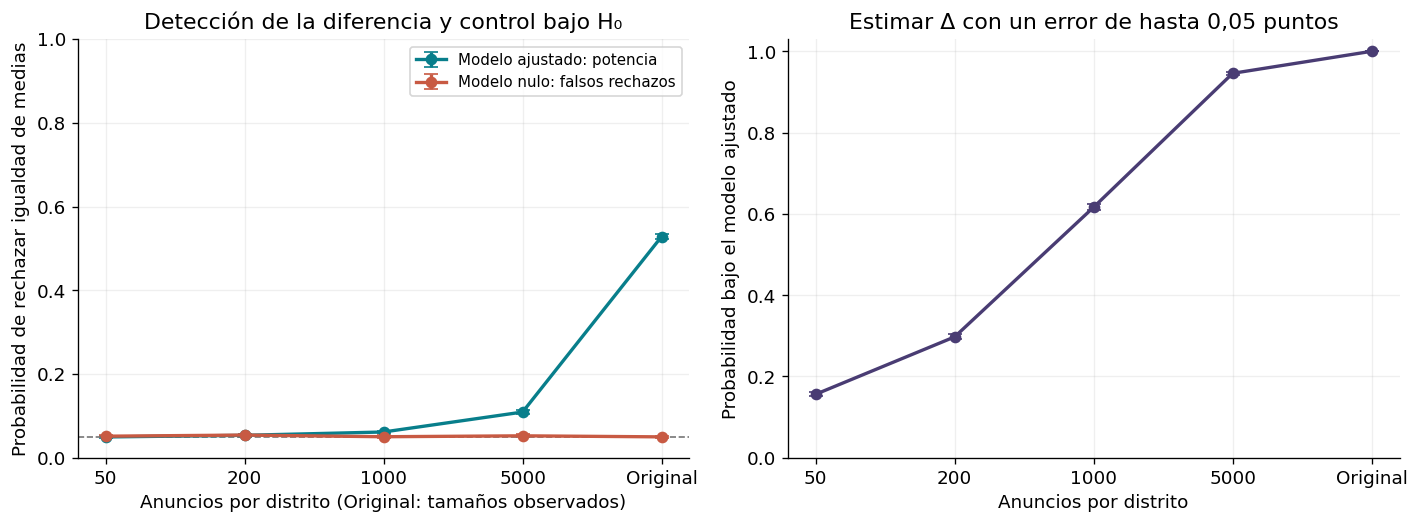

In [13]:
# CELDA DE CÓDIGO 13/18 — Visualizar potencia y precisión según tamaño muestral
# Propósito: mostrar cómo cambia el procedimiento al aumentar la cantidad de anuncios.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Separamos modelos para interpretar correctamente sus tasas de rechazo.
ajustado = mc_tabla[mc_tabla['modelo'].eq('Ajustado')]
nulo = mc_tabla[mc_tabla['modelo'].eq('Nulo')]
# El eje horizontal usa posiciones equiespaciadas de ESCENARIOS,
# no una escala numérica proporcional a sus tamaños.
x_pos = np.arange(len(escenarios))
for tabla, nombre, color in [(ajustado, 'Modelo ajustado: potencia', COLOR_M),
                             (nulo, 'Modelo nulo: falsos rechazos', COLOR_B)]:
    y = tabla['P_rechazo'].to_numpy()
    # errorbar necesita distancias a los límites. vstack organiza error inferior
    # y superior en dos filas, ya que un intervalo Wilson puede ser asimétrico.
    err = np.vstack([y-tabla['IC_MC_rechazo_inf'].to_numpy(),
                     tabla['IC_MC_rechazo_sup'].to_numpy()-y])
    axes[0].errorbar(x_pos, y, yerr=err, marker='o', color=color,
                     capsize=4, linewidth=2, label=nombre)
# La línea del 5% es el nivel nominal de referencia para los falsos rechazos.
axes[0].axhline(ALPHA, color='#757575', linestyle='--', linewidth=1)
axes[0].set_xticks(x_pos, ajustado['escenario'])
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Anuncios por distrito (Original: tamaños observados)')
axes[0].set_ylabel('Probabilidad de rechazar igualdad de medias')
axes[0].set_title('Detección de la diferencia y control bajo H₀')
axes[0].legend(fontsize=9)
# El panel derecho mide cercanía al valor del modelo; el izquierdo mide rechazo de H0.
# Son probabilidades de eventos distintos, aunque se calculen en las mismas muestras.
y = ajustado['P_error_hasta_005'].to_numpy()
axes[1].errorbar(x_pos, y, yerr=np.vstack([
    y-ajustado['IC_MC_precision_inf'].to_numpy(),
    ajustado['IC_MC_precision_sup'].to_numpy()-y]),
    marker='o', color='#493c73', capsize=4, linewidth=2)
axes[1].set_xticks(x_pos, ajustado['escenario'])
axes[1].set_ylim(0, 1.03)
axes[1].set_xlabel('Anuncios por distrito')
axes[1].set_ylabel('Probabilidad bajo el modelo ajustado')
axes[1].set_title('Estimar Δ con un error de hasta 0,05 puntos')
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUT / '03_mc_tamano_muestral.png', dpi=180)
plt.show()


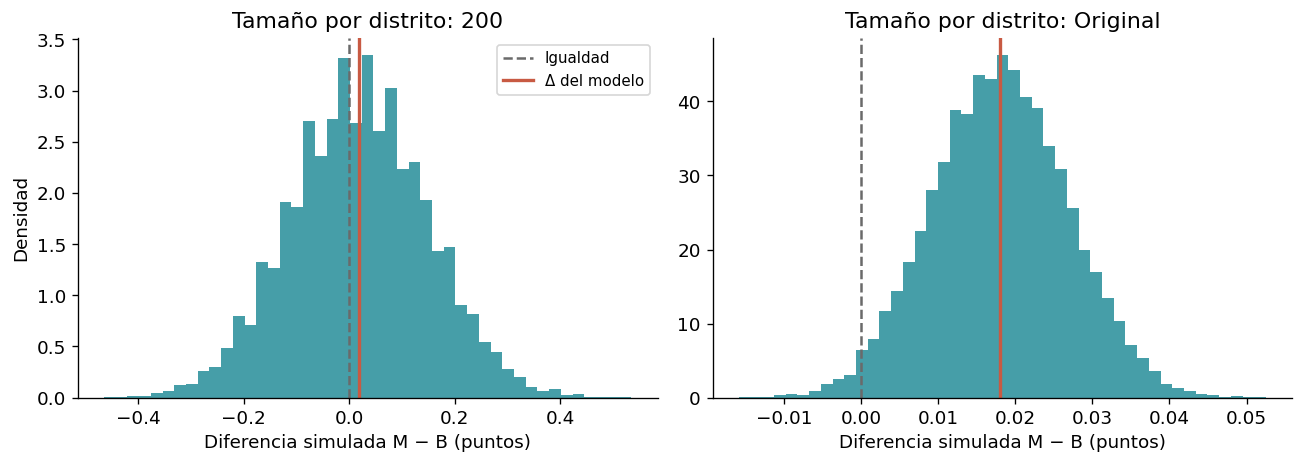

In [14]:
# CELDA DE CÓDIGO 14/18 — Comparar distribuciones de la diferencia simulada
# Propósito: entender visualmente por qué un tamaño mayor produce estimaciones más concentradas.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Comparamos n=200 con los tamaños originales, manteniendo las mismas probabilidades.
for ax, escenario in zip(axes, ['200', 'Original']):
    # Aquí los histogramas contienen diferencias entre medias simuladas.
    # La línea en 0 representa igualdad y la línea en delta es el valor fijado por el modelo.
    # Al aumentar n se estrecha la distribución; el efecto poblacional simulado permanece igual.
    v = simulaciones[(escenario, 'Ajustado')]['delta_sim']
    ax.hist(v, bins=45, density=True, color=COLOR_M, alpha=0.75)
    ax.axvline(0, color='#6a6a6a', linestyle='--', label='Igualdad')
    ax.axvline(delta, color=COLOR_B, linewidth=2, label='Δ del modelo')
    ax.set_title(f'Tamaño por distrito: {escenario}')
    ax.set_xlabel('Diferencia simulada M − B (puntos)')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT / '04_mc_distribuciones.png', dpi=180)
plt.show()


## 7. Interpretación de Monte Carlo

En el modelo ajustado, `P_rechazo` es la **potencia simulada** de la prueba bilateral de Welch para una diferencia igual a la estimada. En el modelo nulo es la tasa de falsos rechazos. Es una evaluación del procedimiento bajo distribuciones especificadas, no una prueba adicional sobre los datos observados.

`P_error_hasta_005` responde: en muestreos repetidos del modelo, ¿qué fracción de diferencias estimadas queda a no más de 0,05 puntos de su valor poblacional dentro del modelo? `P_delta_positiva` describe la estabilidad del signo del estimador. Ninguna de estas cantidades es una probabilidad posterior sobre $\Delta$.

El número de anuncios por distrito controla la variación estadística. El número de realizaciones $R$ controla el error numérico con que aproximamos las probabilidades. Son cantidades distintas.


In [15]:
# CELDA DE CÓDIGO 15/18 — Interpretar las probabilidades simuladas
# Propósito: traducir los resultados a respuestas sobre detección, error y estabilidad del signo.

# iloc[0] obtiene la única fila del escenario correspondiente.
orig = ajustado[ajustado['escenario'].eq('Original')].iloc[0]
pequeno = ajustado[ajustado['escenario'].eq('200')].iloc[0]
# Construimos el texto desde la tabla para que las cifras no queden copiadas a mano.
# {...:.2f} formatea a dos decimales y multiplicar por 100 convierte a porcentaje.
display(Markdown(
    f'Con **200 anuncios por distrito**, la potencia simulada es '
    f'**{100*pequeno.P_rechazo:.2f}%** y la probabilidad de estimar la diferencia '
    f'con error de hasta 0,05 puntos es **{100*pequeno.P_error_hasta_005:.2f}%**. '
    f'Con los tamaños originales, estas cifras son **{100*orig.P_rechazo:.2f}%** '
    f'y **{100*orig.P_error_hasta_005:.2f}%**, respectivamente. '
    f'La probabilidad de obtener una diferencia positiva con tamaños originales '
    f'es **{100*orig.P_delta_positiva:.2f}%** bajo el modelo. '
    'La ganancia de precisión no modifica la magnitud poblacional fijada en la simulación.'))
display(Markdown(
    'Las tasas de falsos rechazos del escenario nulo van de '
    f'**{100*nulo.P_rechazo.min():.2f}% a {100*nulo.P_rechazo.max():.2f}%**. '
    'Se comparan con el nivel nominal del 5% y con sus intervalos de error Monte Carlo. '
    'Las pequeñas diferencias reflejan variación numérica y la aproximación de la prueba. '
    'Un 100% de éxitos simulados no garantiza una probabilidad poblacional de uno.'))

# Un resultado 20.000/20.000 describe estas realizaciones; no demuestra certeza.
# Wilson permite expresar la precisión numérica incluso cuando la proporción es 1.
display(Markdown(f'En el escenario original, la potencia tiene IC Monte Carlo de Wilson '
    f'[{100*orig.IC_MC_rechazo_inf:.2f}%, {100*orig.IC_MC_rechazo_sup:.2f}%]. '
    f'Para el evento de error de hasta {TOL_PRECISION:.2f} puntos, se observaron '
    f'{int((np.abs(simulaciones[("Original", "Ajustado")]["delta_sim"]-delta) <= TOL_PRECISION).sum()):,} éxitos '
    f'en {R:,} realizaciones; el límite inferior Wilson es {100*orig.IC_MC_precision_inf:.2f}%. '
    'Estas probabilidades están condicionadas al modelo ajustado.'))


Con **200 anuncios por distrito**, la potencia simulada es **5.34%** y la probabilidad de estimar la diferencia con error de hasta 0,05 puntos es **29.73%**. Con los tamaños originales, estas cifras son **52.83%** y **100.00%**, respectivamente. La probabilidad de obtener una diferencia positiva con tamaños originales es **98.08%** bajo el modelo. La ganancia de precisión no modifica la magnitud poblacional fijada en la simulación.

Las tasas de falsos rechazos del escenario nulo van de **4.97% a 5.40%**. Se comparan con el nivel nominal del 5% y con sus intervalos de error Monte Carlo. Las pequeñas diferencias reflejan variación numérica y la aproximación de la prueba. Un 100% de éxitos simulados no garantiza una probabilidad poblacional de uno.

En el escenario original, la potencia tiene IC Monte Carlo de Wilson [52.14%, 53.52%]. Para el evento de error de hasta 0.05 puntos, se observaron 20,000 éxitos en 20,000 realizaciones; el límite inferior Wilson es 99.98%. Estas probabilidades están condicionadas al modelo ajustado.

## 8. Conclusiones y limitaciones

Las siguientes conclusiones se generan desde los resultados, para evitar cifras copiadas a mano.


In [16]:
# CELDA DE CÓDIGO 16/18 — Redactar las conclusiones desde los resultados
# Propósito: reunir magnitud, incertidumbre, simulación y alcance de la inferencia.

# Las f-strings insertan los valores calculados en las conclusiones.
# Distinguimos detectar una diferencia de que su magnitud tenga relevancia práctica.
# La interpretación se refiere a los anuncios y supuestos de esta fuente.
display(Markdown(
    f'1. Las medias observadas son **{mu_m:.4f} en Manhattan** y **{mu_b:.4f} en Brooklyn**. '
    f'El contraste es **{delta:.4f} puntos**. Esta comparación específica complementa '
    'la pregunta global de la Entrega 1.\n\n'
    f'2. El EE clásico de la diferencia es **{ee_delta:.6f}** y el bootstrap es '
    f'**{boot[:,2].std(ddof=1):.6f}**. Los intervalos del 95% son '
    f'**[{lo_delta:.4f}, {hi_delta:.4f}]** y **[{boot_lo:.4f}, {boot_hi:.4f}]**, '
    'respectivamente. Ambos métodos describen una diferencia pequeña bajo los supuestos adoptados.\n\n'
    f'3. En el modelo categórico ajustado, la potencia con tamaños originales es '
    f'**{100*orig.P_rechazo:.2f}%**. El tamaño muestral aumenta la precisión y la '
    'posibilidad de detectar una diferencia, aunque su magnitud permanezca pequeña.\n\n'
    '4. El resultado corresponde a anuncios calificados de esta fuente. No permite '
    'atribuir causalidad al distrito ni generalizar sin condiciones al mercado actual de NYC.'))


1. Las medias observadas son **3.2765 en Manhattan** y **3.2585 en Brooklyn**. El contraste es **0.0181 puntos**. Esta comparación específica complementa la pregunta global de la Entrega 1.

2. El EE clásico de la diferencia es **0.008875** y el bootstrap es **0.008844**. Los intervalos del 95% son **[0.0007, 0.0355]** y **[0.0006, 0.0354]**, respectivamente. Ambos métodos describen una diferencia pequeña bajo los supuestos adoptados.

3. En el modelo categórico ajustado, la potencia con tamaños originales es **52.83%**. El tamaño muestral aumenta la precisión y la posibilidad de detectar una diferencia, aunque su magnitud permanezca pequeña.

4. El resultado corresponde a anuncios calificados de esta fuente. No permite atribuir causalidad al distrito ni generalizar sin condiciones al mercado actual de NYC.

### 8.1 Sensibilidad a las calificaciones faltantes

El análisis principal utiliza anuncios con distrito y calificación observados. Para evaluar el papel de las calificaciones ausentes dentro del conjunto registrado, mantenemos los anuncios con distrito conocido y asignamos a todos sus faltantes, alternativamente, las puntuaciones extremas 1 y 5. Para cada distrito, las cotas descriptivas de su media son:

$$L_g=\frac{\sum Y_{gi}+m_g}{N_g},\qquad U_g=\frac{\sum Y_{gi}+5m_g}{N_g}.$$

$N_g$ incluye los anuncios calificados y no calificados del distrito, y $m_g$ es el número de calificaciones faltantes. La diferencia descriptiva del conjunto ampliado queda entre $L_M-U_B$ y $U_M-L_B$. **Son cotas deterministas, no intervalos de confianza.** Cambian el conjunto objetivo respecto al análisis principal y no corrigen anuncios no registrados, distritos ausentes ni errores de medición.


In [17]:
# CELDA DE CÓDIGO 17/18 — Explorar el efecto de las calificaciones faltantes
# Propósito: acotar descriptivamente la diferencia si incorporamos los anuncios sin puntuación.

filas_faltantes = []
# Tomamos todos los anuncios del distrito conocido, incluidos los no calificados.
for distrito in ['Manhattan', 'Brooklyn']:
    x = df.loc[df['neighbourhood_group'].eq(distrito), 'review_rate_number']
    # isna cuenta notas ausentes; sum omite NaN.
    # Para el extremo inferior asignamos 1 a cada ausente y para el superior, 5.
    n_total, n_faltantes = len(x), int(x.isna().sum())
    suma = float(x.sum())
    filas_faltantes.append([distrito, n_total, n_faltantes, n_faltantes/n_total,
        (suma+n_faltantes)/n_total, (suma+5*n_faltantes)/n_total])
sensibilidad_faltantes = pd.DataFrame(filas_faltantes, columns=['distrito', 'n_total',
    'n_faltantes', 'fraccion_faltantes', 'media_minima', 'media_maxima']).set_index('distrito')
# Para minimizar M−B combinamos mínimo de M con máximo de B;
# para maximizarlo combinamos máximo de M con mínimo de B.
# Son extremos deterministas del conjunto ampliado, no intervalos de confianza.
cotas_delta = [float(sensibilidad_faltantes.loc['Manhattan', 'media_minima'] -
                     sensibilidad_faltantes.loc['Brooklyn', 'media_maxima']),
               float(sensibilidad_faltantes.loc['Manhattan', 'media_maxima'] -
                     sensibilidad_faltantes.loc['Brooklyn', 'media_minima'])]
assert sensibilidad_faltantes['n_faltantes'].tolist() == [140, 116]
display(sensibilidad_faltantes)
display(Markdown(f'Las cotas descriptivas de la diferencia al incorporar calificaciones faltantes '
    f'son **[{cotas_delta[0]:.4f}, {cotas_delta[1]:.4f}] puntos**. '
    'Se refieren al conjunto ampliado de anuncios registrados con distrito conocido.'))


,n_total,n_faltantes,fraccion_faltantes,media_minima,media_maxima
distrito,,,,,
Manhattan,43558,140,0.003214,3.269204,3.282061
Brooklyn,41631,116,0.002786,3.252168,3.263313


Las cotas descriptivas de la diferencia al incorporar calificaciones faltantes son **[0.0059, 0.0299] puntos**. Se refieren al conjunto ampliado de anuncios registrados con distrito conocido.

### 8.2 Limitaciones que afectan la interpretación

- **Selección y ausencia de datos:** desconocemos el mecanismo de inclusión en Kaggle y el de las calificaciones faltantes. Eliminar solo los pares incompletos preserva los demás datos, pero no elimina sesgo de selección.
- **Calidad y procedencia:** la Entrega 1 detectó patrones inusuales en precio y calificaciones. Son motivos para limitar la generalización. No constituyen prueba de que los datos sean sintéticos.
- **Dependencia:** IDs distintos no garantizan independencia. Dependencia espacial, temporal o entre propiedades alteraría los EE e intervalos calculados.
- **Escala y agregación:** analizamos puntuaciones ordinales codificadas por anuncio, sin microdatos de huéspedes. Las medias dependen de la interpretación numérica de esa escala.
- **Modelo de simulación:** fijamos las probabilidades empíricas. Monte Carlo estudia comportamiento bajo esas distribuciones y no incorpora incertidumbre de parámetros o escenarios regulatorios y temporales.
- **Alcance del contraste:** Manhattan–Brooklyn cubre solo dos de los cinco distritos. Una diferencia pequeña aquí puede coexistir con diferencias entre otros distritos. La igualdad de medias no equivale a independencia de las variables.

**Mejoras respecto a la interpretación de la Entrega 1:** distinguimos igualdad de medias de independencia, evitamos reportar un p-valor redondeado como cero y expresamos las conclusiones como asociación condicionada al dataset. La V de Cramér y la diferencia de medias cuantifican aspectos distintos. Una asociación pequeña no demuestra ausencia de un efecto causal.


## 9. Exportación y comprobaciones

Se guardan tablas, réplicas, gráficos y un resumen estructurado para que la presentación use las mismas cifras. Las verificaciones contrastan dimensiones originales, limpieza, réplicas y referencias analíticas. Las tolerancias de simulación permiten variación numérica razonable y no sustituyen una revisión conceptual.


In [18]:
# CELDA DE CÓDIGO 18/18 — Comprobar y exportar el análisis
# Propósito: validar cálculos y conservar las cifras utilizadas por la presentación.

# Contrastamos nuestra fórmula clásica con la implementación de Welch de SciPy.
# Este uso de SciPy verifica fórmulas; el bootstrap continúa siendo implementación propia.
welch_check = stats.ttest_ind(M, K, equal_var=False)
ci_check = welch_check.confidence_interval(confidence_level=1-ALPHA)
assert np.allclose([lo_delta, hi_delta], [ci_check.low, ci_check.high], rtol=1e-10)
assert np.isclose(welch_check.statistic, delta/ee_delta)
assert np.isclose(welch_check.df, nu_delta)
# Comprobamos Wilson con casos sin éxitos, todos exitosos y una proporción intermedia.
for e in [np.zeros(20, dtype=bool), np.ones(20, dtype=bool),
          np.array([True]*7 + [False]*13)]:
    check = stats.binomtest(int(e.sum()), len(e)).proportion_ci(method='wilson')
    assert np.allclose(intervalo_wilson(e)[2:], [check.low, check.high])

# Revisamos dimensiones, finitud y coherencia de las réplicas bootstrap.
# allclose e isclose comparan con tolerancias de redondeo; igualdad exacta de floats
# no siempre es adecuada. Las tolerancias de simulación admiten error numérico.
assert boot.shape == (B, 3) and np.isfinite(boot).all()
assert np.allclose(boot[:, 2], boot[:, 0] - boot[:, 1])
assert np.all(np.abs(check_boot['error_relativo']) < 0.08)
assert np.all(np.abs(verificacion_mc['razon_sim_teoria'] - 1) < 0.05)
# Verificamos que cada simulación tenga R realizaciones y diferencias posibles.
# Una diferencia entre medias de puntuaciones 1–5 debe estar entre −4 y 4.
# El promedio de las diferencias simuladas debe estar cerca del efecto del modelo.
for (etiqueta, modelo), sim in simulaciones.items():
    assert len(sim) == R and np.isfinite(sim[['delta_sim', 'EE_sim']]).all().all()
    assert sim['delta_sim'].between(-4, 4).all()
    fila = mc_tabla[(mc_tabla['escenario'].eq(etiqueta)) & mc_tabla['modelo'].eq(modelo)].iloc[0]
    verdad = delta if modelo == 'Ajustado' else 0.0
    ee_centro = sim['delta_sim'].std(ddof=1) / np.sqrt(R)
    assert abs(sim['delta_sim'].mean()-verdad) < 5*ee_centro

# CSV conserva tablas para consultarlas con otras herramientas.
resumen_distritos.to_csv(OUT / 'resumen_distritos.csv')
comparacion.to_csv(OUT / 'comparacion_estimacion.csv')
estabilidad_boot.to_csv(OUT / 'estabilidad_bootstrap.csv', index=False)
mc_tabla.to_csv(OUT / 'monte_carlo_escenarios.csv', index=False)
convergencia_mc.to_csv(OUT / 'convergencia_monte_carlo.csv', index=False)
probabilidades.to_csv(OUT / 'probabilidades_modelo.csv', index=False)
sensibilidad.to_csv(OUT / 'sensibilidad_umbrales.csv', index=False)
# NPZ conserva los vectores de réplicas comprimidos para revisar distribuciones.
np.savez_compressed(OUT / 'replicas_simulacion.npz', bootstrap=boot,
    **{f'mc_{e}_{m}': s['delta_sim'].to_numpy() for (e,m),s in simulaciones.items()})

sensibilidad_faltantes.to_csv(OUT / 'sensibilidad_faltantes.csv')

# También exportamos coordenadas de histogramas para los gráficos de la presentación.
# Los centros de intervalos se calculan promediando sus dos bordes.
hist_y, hist_bordes = np.histogram(boot[:, 2], bins=30, density=True)
# JSON reúne resultados, parámetros, versiones y controles en un formato estructurado.
# to_dict y tolist convierten tablas y vectores a objetos que JSON puede guardar.
resumen = {'grupo': 25, 'dataset_sha256': sha256, 'versiones': versiones,
    'semillas': {'bootstrap': SEED_BOOT, 'monte_carlo': SEED_MC},
    'B': B, 'R': R, 'alpha': ALPHA, 'tolerancia_precision': TOL_PRECISION,
    'auditoria': auditoria, 'n_pares_cinco_distritos': len(pares),
    'estimacion': comparacion.reset_index().to_dict(orient='records'),
    'monte_carlo': mc_tabla.to_dict(orient='records'),
    'estabilidad_bootstrap': estabilidad_boot.to_dict(orient='records'),
    'convergencia_mc': convergencia_mc.to_dict(orient='records'),
    'probabilidades': probabilidades.to_dict(orient='records'),
    'entrega1': {'F_anova': float(f_e1), 'p_anova': float(p_anova_e1),
                  'chi2': float(chi2_e1), 'p_chi2': float(p_chi2_e1), 'V_cramer': float(v_e1)},
    'sensibilidad_faltantes': sensibilidad_faltantes.reset_index().to_dict(orient='records'),
    'cotas_delta_faltantes': cotas_delta,
    'bootstrap_densidad': {'x': ((hist_bordes[:-1]+hist_bordes[1:])/2).tolist(),
                          'y': hist_y.tolist()}}
resumen['bootstrap_medias_densidad'] = {}
for j, distrito in enumerate(['Manhattan', 'Brooklyn']):
    y, bordes = np.histogram(boot[:, j], bins=30, density=True)
    resumen['bootstrap_medias_densidad'][distrito] = {'x': ((bordes[:-1]+bordes[1:])/2).tolist(), 'y': y.tolist()}
(OUT / 'resumen_resultados.json').write_text(json.dumps(resumen, ensure_ascii=False, indent=2), encoding='utf-8')
print('Comprobaciones aprobadas. Resultados guardados en:', OUT.name)


Comprobaciones aprobadas. Resultados guardados en: resultados


## Mapa de las celdas y relación con el enunciado

| Código | Qué hace | Para qué sirve en la entrega |
|---|---|---|
| 1–3 | Configura, limpia, selecciona y recalcula antecedentes | Continuidad con los datos y la pregunta de la Entrega 1 |
| 4–5 | Estima medias, diferencia e IC clásicos y los grafica | Estimación puntual y referencia para comparar incertidumbre |
| 6–8 | Implementa bootstrap, grafica y comprueba su estabilidad | Función propia, procedimiento, distribución e interpretación |
| 9 | Compara clásico y bootstrap | Evaluar concordancia y diferencias entre enfoques |
| 10–11 | Define distribuciones y simula tamaños y modelos | Situación, modelo, supuestos e implementación Monte Carlo |
| 12 | Estudia convergencia y referencia analítica | Justificar el número de realizaciones y su estabilidad |
| 13–15 | Grafica e interpreta potencia y precisión | Explicar las implicaciones prácticas de la simulación |
| 16–17 | Concluye y explora faltantes | Interpretación y límites; faltantes es un análisis complementario |
| 18 | Comprueba y exporta tablas y réplicas | Reproducibilidad y coherencia con la presentación |

Las **propiedades de los estimadores** —sesgo, consistencia y eficiencia bajo sus condiciones— se explican en la sección 3. El **origen y relevancia moderna del bootstrap** se explican en la sección 4. Son argumentos conceptuales: ejecutar código no sustituye explicarlos.

**Pregunta de control:** ¿puede aumentar la potencia sin que cambie la diferencia del modelo? Sí: aumentar el tamaño muestral reduce la variabilidad de las medias, haciendo más fácil detectar el mismo efecto pequeño.


## Referencias

1. Efron, B. (1979). *Bootstrap Methods: Another Look at the Jackknife*. The Annals of Statistics, 7(1), 1–26. [DOI: 10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552).
2. Shalizi, C. R. (2018). *Simulation for Inference I — The Bootstrap*. Carnegie Mellon University, notas docentes. [Documento](https://stat.cmu.edu/~cshalizi/dst/18/lectures/18/lecture-18.html).
3. National Institute of Standards and Technology. *Monte Carlo Tool*. [Descripción institucional](https://www.nist.gov/services-resources/software/monte-carlo-tool).
4. NumPy. *numpy.random.Generator.multinomial*. [Documentación oficial](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.multinomial.html).
5. Airbnb Open Data (NYC), versión 1. [Kaggle](https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata). Fuente compartida con la Entrega 1.
6. INF280, UTFSM. *Laboratorio 2 — Simulación e Inferencia*. Enunciado entregado al grupo, 28 de septiembre de 2026.

7. SciPy. *ttest_ind*: prueba de Welch e intervalo de confianza. [Documentación oficial](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).
8. NIST/SEMATECH. *Confidence limits for a binomial proportion*: intervalo de Wilson. [Manual](https://www.itl.nist.gov/div898/handbook/prc/section2/prc241.htm).
9. NumPy. *Compatibility policy*: condiciones de reproducibilidad de los generadores aleatorios. [Documentación oficial](https://numpy.org/doc/stable/reference/random/compatibility.html).

**Ejecución:** abrir este archivo en Jupyter o VS Code, reiniciar el kernel y ejecutar todas las celdas en orden. En Colab, subir también el CSV y situarlo en `data/Airbnb_Open_Data.csv`. El archivo `requirements.txt` contiene las versiones utilizadas para esta ejecución.
